In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
import openpyxl
warnings.filterwarnings('ignore')
import shutil
from pathlib import Path

In [2]:
data = Path(r'data\online+retail.zip')
extract = Path(r'extracted_data')
extract.mkdir(parents=True, exist_ok=True)
shutil.unpack_archive(data, extract)

In [3]:
orig_df = pd.read_excel(extract / 'Online Retail.xlsx')
orig_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print(orig_df.shape)
orig_df.columns

(541909, 8)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [5]:
orig_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
#convert the datatype of custoerm id to int
#orig_df['CustomerID'] = orig_df['CustomerID'].astype('Int64')

lets find the mssing values 

In [7]:
orig_df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
(5268/orig_df.shape[0])*100

0.9721189350979592

In [9]:
orig_df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


#lets look for duplicates

In [10]:
orig_df.duplicated().sum()

np.int64(5268)

Lets check the categories and see the unique

In [11]:
orig_df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

In [12]:
cat_cols =  orig_df.select_dtypes(include='object').columns
cat_cols

Index(['InvoiceNo', 'StockCode', 'Description', 'Country'], dtype='str')

So from our initial analysis of the messy data, we found that each row is a transacvtion line, product within an order , not a full order, meaning one custoemr could have selected many products uder the same cart and then checked out all as one order. we can verify this claim by looking at the invoiceNo, date and customerId, usually many differrnt product descriptuions for 1 customer all under the same invoice and bought on the same darta.
Key insssues identified:
1. missing values in teh customerid atleast 24% of the whole data
2. negative quantities which could potentially indicate returns hence careful ahndling
3. also theres around 1% duyplicate values in the data which can inflate the revenue and or lose if not handled.
4. Differnt labels for ther same region, ie EIRE and IReland .needs to be standardised

Impact on analysis. if these insights arent correctly handled, the revenue analysis, customer segmnentation and geographic insights 
could be flawed or biased if these arent dealt with.

In [13]:
orig_df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

1. Revenue Handling
Separate sales (positive quantity) and returns (negative quantity)
Compute:
gross revenue
returns value
net revenue
2. CustomerID Handling
Convert to string
Keep missing values for overall analysis
Exclude missing CustomerID only for customer-level insights
3. Duplicates
Identify exact duplicates
Inspect before removal
Drop only confirmed duplicates
4. Country Standardization
Use dictionary mapping
Standardize inconsistent labels (EIRE → Ireland, etc.)
5. Data Type Fixes
Convert dates to datetime
Ensure numeric columns are properly typed
6. Optional (Bonus)
Remove rows with:
zero price
invalid quantity (if clearly erroneous)

Lets start cleaning the data

In [14]:
orig_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [15]:
#fix data type
orig_df['CustomerID'] = orig_df['CustomerID'].astype('str')

#cnvert to datetime
orig_df['InvoiceDate'] = pd.to_datetime(orig_df['InvoiceDate'])
#numeric columns muyst be numeric
orig_df['Quantity'] = pd.to_numeric(orig_df['Quantity'], errors='coerce')
orig_df['UnitPrice'] = pd.to_numeric(orig_df['UnitPrice'], errors='coerce')


In [16]:
orig_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  str           
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), object(3), str(2)
memory usage: 33.1+ MB


In [17]:
#missing_values
orig_df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
#handle customerId
orig_df['CustomerID']= orig_df['CustomerID'].fillna('Unknown')

In [19]:
#drop critical rows, ie quantity and unit prioce
orig_df.dropna(subset=['Quantity', 'UnitPrice'], inplace=True)

In [20]:
#Decription low priorty  fix
orig_df['Description']= orig_df['Description'].fillna('Unknown')

In [21]:
orig_df.duplicated().sum()

np.int64(5268)

In [22]:
#drop duplicates
orig_df.drop_duplicates(inplace=True)

Lets now deal witht eh country names


In [23]:
orig_df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

Lets ix the unclear countrys. althouhg we can see those like Channel islands, unspecified and European community,
and then we have the rsa, usa and eire

In [24]:
country_map = {
    'EIRE': 'Ireland',
    'RSA': "South Africa",
    'USA': "United States",
    
}
orig_df['Country'] = orig_df['Country'].replace(country_map)
orig_df['Country'] = orig_df['Country'].str.strip() #to remove the whitepace before an aafter teh country nmame

In [25]:
#now the ambiguous country names have been fixed, we can check the unique values again
orig_df['Country'] = orig_df['Country'].replace({
    'Unspecified': 'Other',
    'European Community': 'Other'
})

orig_df['Country'] = orig_df['Country'].fillna('Other')

In [26]:
orig_df['Country'].nunique()
orig_df['Country'].unique()

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
              'Ireland',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',                'Other',
               'Brazil',        'United States',                'Malta',
         'South Africa']
Length: 37, dtype: str

#now lets handle returns


In [27]:
orig_df['is_return'] = orig_df['Quantity'] < 0


#now we create revenue columns. where our analysis lies

In [28]:
orig_df['Revenue'] = orig_df['Quantity'] * orig_df['UnitPrice']

In [29]:
orig_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


In [30]:
#separate sales from returns
orig_df['SalesRevenue'] = orig_df.apply(lambda x: x['Revenue'] if x['Quantity'] > 0 else 0, axis=1)
orig_df['ReturnValue'] = orig_df.apply(lambda x: abs(x["Revenue"]) if x['Quantity'] < 0 else 0, axis=1)


In [31]:
net_revenue = orig_df['Revenue'].sum()
All_sales = orig_df['SalesRevenue'].sum()
returns = orig_df['ReturnValue'].sum()
print(f"Gross Revenue show net impact after returns: {net_revenue}")
print(f"Total Sales: {All_sales}")
print(f"Returns: {returns}")


Gross Revenue show net impact after returns: 9726006.954
Total Sales: 10619986.684
Returns: 893979.73


In [32]:
#check where teh quanituy is 0 and unit price is less than 0
orig_df[(orig_df['Quantity'] == 0)]
orig_df[(orig_df['UnitPrice'] < 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return,Revenue,SalesRevenue,ReturnValue
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,Unknown,United Kingdom,False,-11062.06,-11062.06,0.0
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,Unknown,United Kingdom,False,-11062.06,-11062.06,0.0


3so we cant have negative unit price, so we need to eremove that


In [33]:
orig_df = orig_df[orig_df['UnitPrice'] >0]
orig_df.shape

(534129, 12)

In [34]:
orig_df = orig_df[orig_df['Quantity'] != 0]

In [35]:
#final clean dataset 
df_clean = orig_df.copy()
print(df_clean.shape)
df_clean.head()


(534129, 12)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return,Revenue,SalesRevenue,ReturnValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,15.30,0.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,20.34,0.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,22.00,0.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,20.34,0.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,20.34,0.0


In [36]:
df_clean['CustomerID'].nunique()

4372

lets create a custoemr datasef for later


In [37]:
customer_df = df_clean.dropna(subset=['CustomerID']).groupby('CustomerID').agg({
    'Country': lambda x:x.mode()[0] if not x.mode().empty else x.iloc[0]
}).reset_index()
customer_df.shape

(4372, 2)

SAVe teh cleaned data


In [38]:
df_clean.to_csv('data/cleaned_online_retail.csv', index=False)
customer_df.to_csv('data/cleaned_customer_data.csv', index=False)

SalesRevenue represents income from positive transactions only, while Revenue includes both sales and returns. The difference between them reflects the impact of returns on overall performance.
I retained rows with missing CustomerID because they still represent valid transactions. Dropping them would remove a significant portion of revenue and bias analysis. I only exclude them when performing customer-level analysis.
I only remove exact duplicates after inspection. Removing duplicates blindly can eliminate legitimate transactions and distort revenue calculations.
I separated returns instead of removing them because they provide insight into product performance and customer behavior. Including them allows for accurate net revenue calculation.


PART 2 using sql

In [39]:
import sqlite3


In [40]:
#create a connection to the database
conn = sqlite3.connect('Week1.db')

In [41]:
df_clean.to_sql('cleaned_online_retail', conn, if_exists='replace', index=False)
customer_df.to_sql('cleaned_customer_data',conn, if_exists='replace', index=False)

4372

In [42]:
pd.read_sql('SELECT * FROM sqlite_master WHERE type="table";', conn)

,type,name,tbl_name,rootpage,sql
0,table,cleaned_online_retail,cleaned_online_retail,2,"CREATE TABLE ""cleaned_online_retail"" (\n""Invoi..."
1,table,cleaned_customer_data,cleaned_customer_data,15888,"CREATE TABLE ""cleaned_customer_data"" (\n""Custo..."


so well start writing queries and usng pd.read_sql('query',conn)

In [43]:
query = ''' SELECT ROUND(SUM(SalesREvenue),2) as Total_SALES_REVENUE
from cleaned_online_retail

'''
print(f'total sales revenue is {pd.read_sql(query,conn).iloc[0,0]}')
pd.read_sql(query, conn)


total sales revenue is 10642110.8


,Total_SALES_REVENUE
0,10642110.8


In [44]:
#finid th total return value
query= """
select ROUND(SUM(ReturnValue),2) as Total_Return_Value from cleaned_online_retail
"""
pd.read_sql(query, conn)

,Total_Return_Value
0,893979.73


In [45]:
#net revenue
query = """SELECT ROUND(SUM(Revenue),2) as NET_REVENUE
from cleaned_online_retail
"""
print('This gives the final net revenue after the returns')
pd.read_sql(query, conn)

This gives the final net revenue after the returns


,NET_REVENUE
0,9748131.07


In [46]:
8189252.30*100/9748131.07


84.00843444957906

In [47]:
#revenue by country
query = '''
select Country, ROUND(SUM(Revenue),2) as Total_Revenue_Per_Country
from cleaned_online_retail
group by Country
order by Total_Revenue_Per_Country DESC'''
pd.read_sql(query, conn)

,Country,Total_Revenue_Per_Country
0,United Kingdom,8189252.30
1,Netherlands,284661.54
2,Ireland,262993.38
3,Germany,221509.47
4,France,197317.11
5,Australia,137009.77
6,Switzerland,56363.05
7,Spain,54756.03
8,Belgium,40910.96
9,Sweden,36585.41


we can see the uk dominating followed by close time betweeen netherlands and ireland

In [48]:
#top products by revenue
pd.read_sql("""
select StockCode, Description, 
Round(SUM(SalesRevenue),2) as Sales_Revenue
from cleaned_online_retail
            where StockCode != "DOT"
group by StockCode, Description
order by Sales_Revenue DESC
limit 10
""", conn)

,StockCode,Description,Sales_Revenue
0,22423,REGENCY CAKESTAND 3 TIER,174156.54
1,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24
3,47566,PARTY BUNTING,99445.23
4,85099B,JUMBO BAG RED RETROSPOT,94159.81
5,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92
6,POST,POSTAGE,78101.88
7,M,Manual,77750.27
8,23084,RABBIT NIGHT LIGHT,66870.03
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59


In [49]:
#top 10 customers by revenue
query = """
select CustomerID, Country, ROUND(Sum(SalesRevenue),2) as customer_revenue
from cleaned_online_retail
where CustomerID != 'None' AND CustomerID IS NOT NULL AND CustomerID != 'Unknown'
group by CustomerID
ORDER by customer_revenue DESC
limit 10
"""
pd.read_sql(query, conn)

,CustomerID,Country,customer_revenue
0,14646.0,Netherlands,280206.02
1,18102.0,United Kingdom,259657.30
2,17450.0,United Kingdom,194390.79
3,16446.0,United Kingdom,168472.50
4,14911.0,Ireland,143711.17
5,12415.0,Australia,124914.53
6,14156.0,Ireland,117210.08
7,17511.0,United Kingdom,91062.38
8,16029.0,United Kingdom,80850.84
9,12346.0,United Kingdom,77183.60


In [50]:
#revenue by month
print('This is good for one dashboard trend chart. It shows the revenue trend over time, which can help identify seasonal patterns, growth trends, or any anomalies in sales performance.')
pd.read_sql("""
SELECT 
    strftime('%Y-%m', InvoiceDate) AS month,
    ROUND(SUM(SalesRevenue), 2) AS monthly_revenue
FROM cleaned_online_retail
GROUP BY month
ORDER BY month;
""", conn)

This is good for one dashboard trend chart. It shows the revenue trend over time, which can help identify seasonal patterns, growth trends, or any anomalies in sales performance.


,month,monthly_revenue
0,2010-12,821452.73
1,2011-01,689811.61
2,2011-02,522545.56
3,2011-03,716215.26
4,2011-04,536968.49
5,2011-05,769296.61
6,2011-06,760547.01
7,2011-07,718076.12
8,2011-08,757841.38
9,2011-09,1056435.19


In [51]:
#high volume products vs high cost produrtcs
pd.read_sql("""
SELECT 
    StockCode,
    Description,
    SUM(CASE WHEN Quantity > 0 THEN Quantity ELSE 0 END) AS total_units_sold,
    ROUND(SUM(SalesRevenue), 2) AS sales_revenue
FROM cleaned_online_retail
GROUP BY StockCode, Description
ORDER BY sales_revenue DESC
LIMIT 10;
""", conn)

,StockCode,Description,total_units_sold,sales_revenue
0,DOT,DOTCOM POSTAGE,706,206248.77
1,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54
2,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24
4,47566,PARTY BUNTING,18283,99445.23
5,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81
6,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92
7,POST,POSTAGE,3150,78101.88
8,M,Manual,6984,77750.27
9,23084,RABBIT NIGHT LIGHT,30739,66870.03


In [52]:
#products that were returned the most
pd.read_sql(''' 
select StockCode, Description,
            ROUND(SUM(ReturnValue),2) as Total_Returns
            from cleaned_online_retail
            where is_return = 1
            group by StockCode, Description
            order by Total_Returns Desc
            limit 10
''', conn)

,StockCode,Description,Total_Returns
0,AMAZONFEE,AMAZON FEE,235281.59
1,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2,M,Manual,146784.46
3,23166,MEDIUM CERAMIC TOP STORAGE JAR,77479.64
4,POST,POSTAGE,11871.24
5,22423,REGENCY CAKESTAND 3 TIER,9697.05
6,CRUK,CRUK Commission,7933.43
7,BANK CHARGES,Bank Charges,7340.64
8,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6624.30
9,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,6591.42


“Revenue is highly concentrated in the United Kingdom, which contributes approximately 84% of total sales. This indicates strong market dependence and exposes the business to geographic risk. To mitigate this, the company should explore growth opportunities in underperforming regions and diversify its customer base.
Some top revenue contributors (e.g., DOTCOM POSTAGE) are service-related charges rather than products, so product-level analysis should exclude these to avoid misleading conclusions.
While high-selling products show higher return volumes, this may be driven by scale. A return rate analysis is needed to identify genuinely problematic products.
Reveneue ios concentrated arounda  small chunk of custoeors, indicating dependence and reliance on high-vcalue client and potential risk to the buesiness if they churn

Recreatuing opouyr results with PYTHON

In [53]:
#revenue by country
country_rev = (
    df_clean.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)

)
country_rev.head()

Country
United Kingdom    8189252.304
Netherlands        284661.540
Ireland            262993.380
Germany            221509.470
France             197317.110
Name: Revenue, dtype: float64

In [54]:
df_prod = df_clean[~df_clean['Description'].str.contains('POSTAGE', case=False, na=False)]

#remvoed postage snce it i9snt a product and it has a high return value which is skewing the data
top_products = df_prod.groupby('Description')['SalesRevenue'].sum().sort_values(ascending=False).head(10)

top_products

Description
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
PAPER CHAIN KIT 50'S CHRISTMAS         64875.59
ASSORTED COLOUR BIRD ORNAMENT          58927.62
Name: SalesRevenue, dtype: float64

In [55]:
#cuatomer revenue
cust_rev = (
    df_clean[df_clean['CustomerID'] !='Unknown']
    .groupby('CustomerID')[['SalesRevenue']].sum()
    .sort_values(by='SalesRevenue', ascending=False)
)
cust_rev.head(10)

,SalesRevenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


In [56]:
#monthly trend
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_rev = df_clean.groupby('Month')['SalesRevenue'].sum()
monthly_rev

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: SalesRevenue, dtype: float64

In [57]:
top_10_pct = cust_rev.head(10).sum() / cust_rev.sum()
top_10_pct = top_10_pct*100
top_10_pct

SalesRevenue    17.301936
dtype: float64

THEN WE DO THE GRAPHING

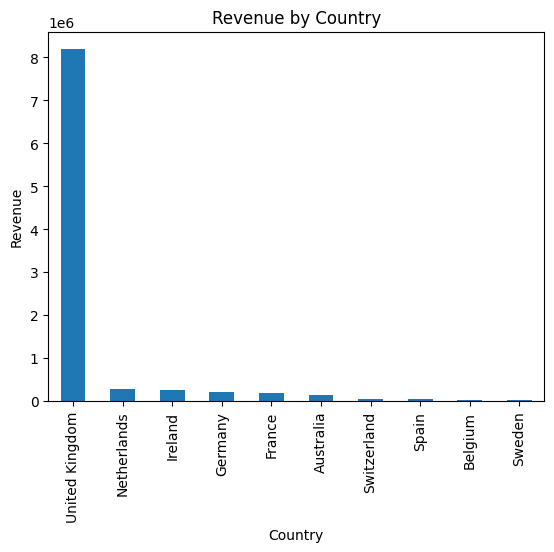

In [58]:
#chart1 revne by country
import matplotlib.pyplot as plt

country_rev.head(10).plot(kind='bar')
plt.title('Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.show()

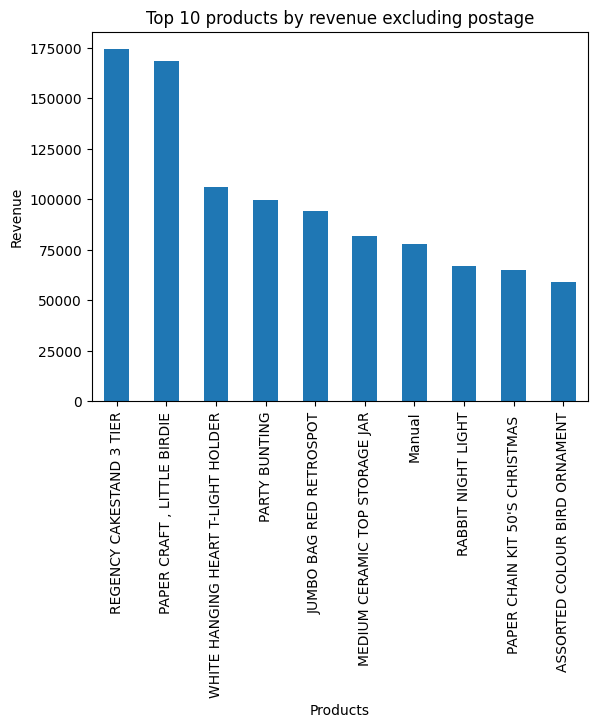

In [59]:
#chart2 top products without postage
top_products.plot(kind='bar')
plt.title('Top 10 products by revenue excluding postage')
plt.xlabel('Products')
plt.ylabel("Revenue")
plt.show()

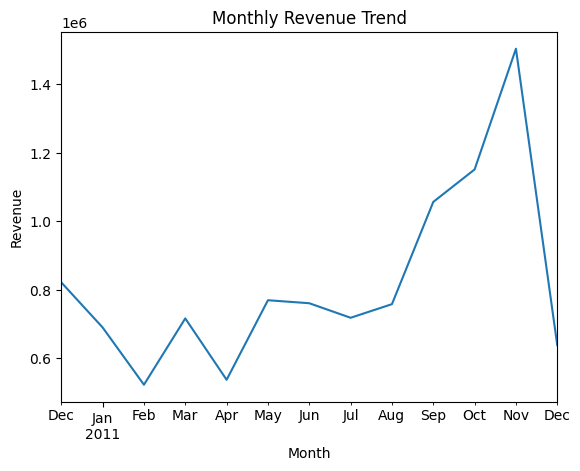

In [60]:
#   Chart 3 monthly trend
monthly_rev.plot()
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.show()

In [65]:
top_countries = (
    df_clean.groupby('Country')['SalesRevenue']
    .sum().sort_values(ascending=False)
    .head(10)
    .index
)
df_clean['Country_Grouped'] = df_clean['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

Export the data fro the dashboard

In [67]:
df_clean.to_csv('data\dashboard_data_cor.csv', index=False)